# DIP Lab 01 – Tách kênh màu video + chèn icon
**Đề bài:** chèn một ảnh nhỏ (icon) lên video, rồi hiển thị một cửa sổ 4 subplot: video gốc + 3 kênh R, G, B (đều có icon).

Notebook không phát video realtime được, nên:
- Phần 1–3 xử lý và hiển thị **một số frame mẫu** (đủ để thấy kết quả).
- Phần 4 có hàm `play()` để xem realtime trong cửa sổ OpenCV khi chạy trên máy.

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

BASE_DIR = Path.cwd()          # Jupyter/VS Code chạy notebook với thư mục hiện tại = thư mục chứa notebook
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

VIDEO_PATH = DATA_DIR / "input.mkv"
ICON_PATH = DATA_DIR / "icon_big.png"
W, H = 640, 360        # kích thước hiển thị cố định
POS_X, POS_Y = 20, 20  # góc trên-trái của icon

## 1. Đọc icon kèm kênh alpha và chèn bằng alpha blending
- PNG có kênh thứ 4 (alpha = độ đục). `cv2.imread` mặc định **bỏ** kênh này → phải dùng `IMREAD_UNCHANGED`.
- Alpha blending: `out = α·icon + (1 − α)·frame`. Icon tự bị cắt nếu vượt khung hình.

Icon: (90, 90, 3) – có alpha: True


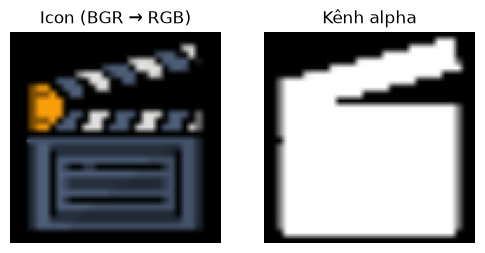

In [2]:
def load_icon(path):
    """Trả về (ảnh BGR, alpha ∈ [0, 1] dạng H×W×1)."""
    icon = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if icon is None:
        raise FileNotFoundError(path)
    if icon.ndim == 3 and icon.shape[2] == 4:
        return icon[:, :, :3], icon[:, :, 3:4].astype(np.float32) / 255.0
    if icon.ndim == 2:
        icon = cv2.cvtColor(icon, cv2.COLOR_GRAY2BGR)
    return icon, np.ones((*icon.shape[:2], 1), dtype=np.float32)


def overlay(frame, icon_bgr, alpha, x, y):
    h = min(icon_bgr.shape[0], frame.shape[0] - y)
    w = min(icon_bgr.shape[1], frame.shape[1] - x)
    if h <= 0 or w <= 0:
        return frame
    roi = frame[y:y + h, x:x + w].astype(np.float32)
    a = alpha[:h, :w]
    frame[y:y + h, x:x + w] = (a * icon_bgr[:h, :w] + (1 - a) * roi).astype(np.uint8)
    return frame


icon_bgr, icon_alpha = load_icon(ICON_PATH)
print("Icon:", icon_bgr.shape, "– có alpha:", bool((icon_alpha < 1).any()))

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(cv2.cvtColor(icon_bgr, cv2.COLOR_BGR2RGB)); axes[0].set_title("Icon (BGR → RGB)")
axes[1].imshow(icon_alpha[:, :, 0], cmap="gray"); axes[1].set_title("Kênh alpha")
for ax in axes:
    ax.axis("off")
plt.show()

## 2. Tách kênh màu
- Chèn icon **trước** khi tách kênh → cả 3 kênh đều có icon.
- Mỗi kênh đặt vào đúng vị trí trong ảnh RGB rỗng để hiển thị bằng chính màu của nó.
- OpenCV lưu **BGR**, Matplotlib hiển thị **RGB** → đảo `frame[..., ::-1]`.

In [3]:
def split_channels(frame_bgr):
    frame = cv2.resize(frame_bgr, (W, H))
    frame = overlay(frame, icon_bgr, icon_alpha, POS_X, POS_Y)
    b, g, r = cv2.split(frame)
    rgb = frame[..., ::-1]
    red = np.zeros_like(rgb); red[:, :, 0] = r
    green = np.zeros_like(rgb); green[:, :, 1] = g
    blue = np.zeros_like(rgb); blue[:, :, 2] = b
    return rgb, red, green, blue


TITLES = ("Original + Icon", "Red Channel + Icon", "Green Channel + Icon", "Blue Channel + Icon")


def show_grid(images, suptitle=None, save_as=None):
    fig, axs = plt.subplots(2, 2, figsize=(10, 6))
    for ax, img, title in zip(axs.ravel(), images, TITLES):
        ax.imshow(img); ax.set_title(title); ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle)
    plt.tight_layout()
    if save_as:
        plt.savefig(OUTPUT_DIR / save_as, dpi=90, bbox_inches="tight")
    plt.show()

## 3. Kết quả trên các frame mẫu

Video: 1043 frame, 30.0 fps, ~34.8 giây


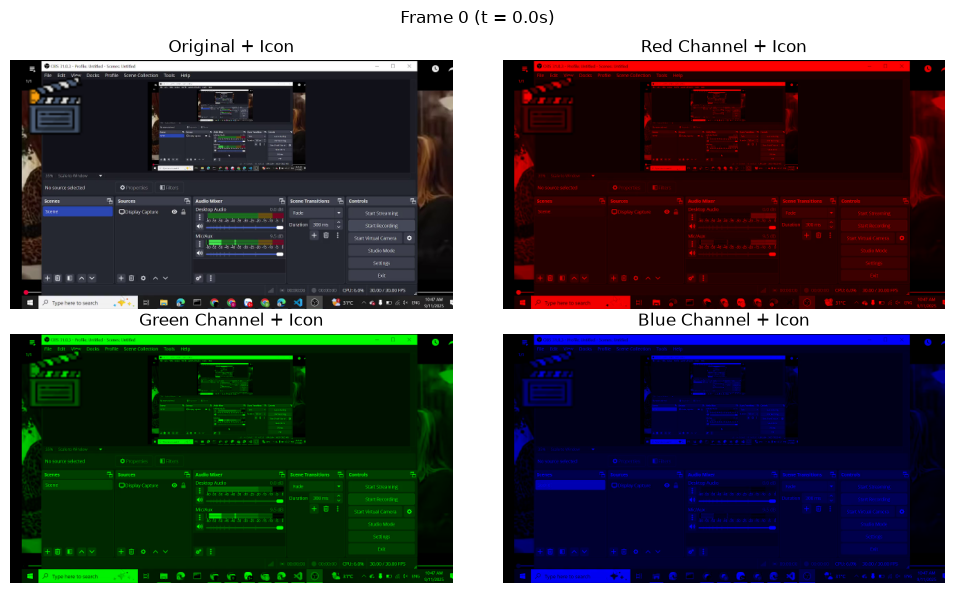

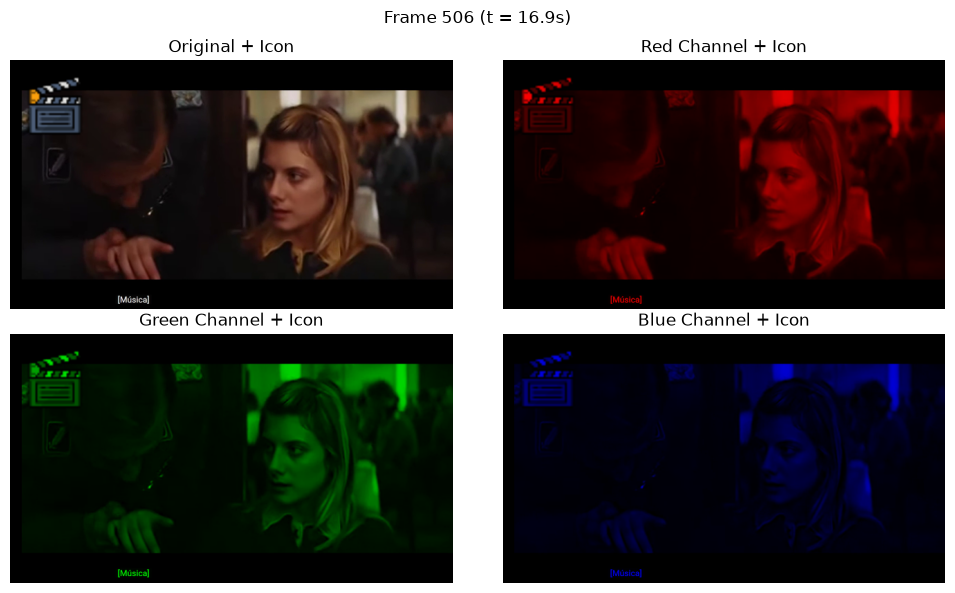

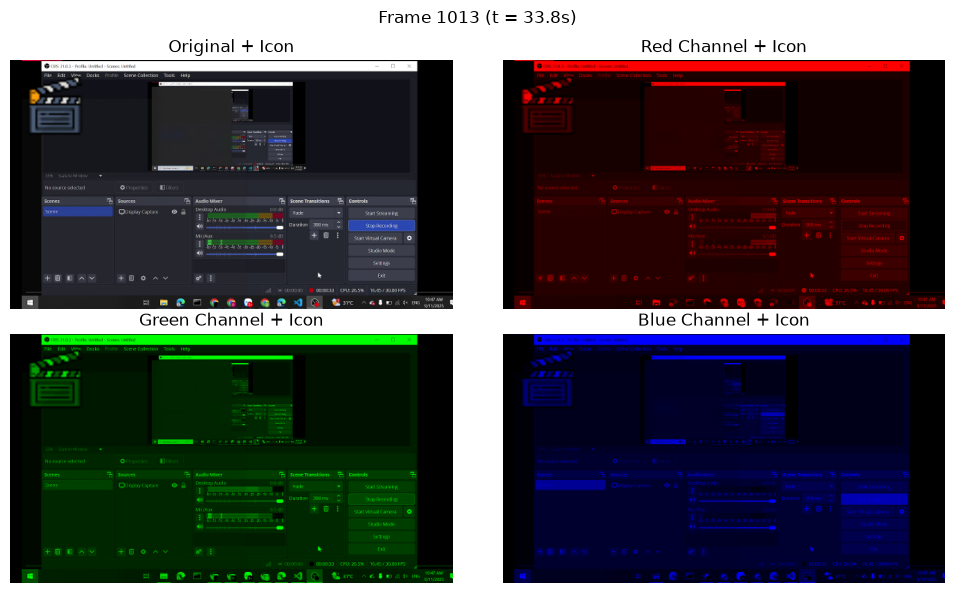

In [4]:
capture = cv2.VideoCapture(str(VIDEO_PATH))
n_frames = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))
fps = capture.get(cv2.CAP_PROP_FPS) or 30.0
print(f"Video: {n_frames} frame, {fps:.1f} fps, ~{n_frames / fps:.1f} giây")

for i, idx in enumerate(np.linspace(0, n_frames - int(fps), 3, dtype=int)):
    capture.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
    ok, frame = capture.read()
    if not ok:
        continue
    show_grid(split_channels(frame), suptitle=f"Frame {idx} (t = {idx / fps:.1f}s)",
              save_as="preview.png" if i == 0 else None)
capture.release()

## 4. Xem realtime (chạy trên máy)
Bỏ dấu `#` ở dòng cuối rồi chạy cell. Ghép 4 ảnh thành lưới 2×2 và hiển thị bằng `cv2.imshow`
(nhanh hơn Matplotlib nhiều). Nhấn **q** để thoát.

In [5]:
def play(skip=1):
    cap = cv2.VideoCapture(str(VIDEO_PATH))
    delay = int(1000 / (cap.get(cv2.CAP_PROP_FPS) or 30))
    count = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if count % skip == 0:
            rgb, red, green, blue = split_channels(frame)
            grid = np.vstack([np.hstack([rgb, red]), np.hstack([green, blue])])[..., ::-1]  # về lại BGR cho OpenCV
            cv2.imshow("Original | Red / Green | Blue  (q để thoát)", grid)
            if cv2.waitKey(delay) & 0xFF == ord("q"):
                break
        count += 1
    cap.release()
    cv2.destroyAllWindows()


# play()